# 🔥 Algerian Forest Fire — FWI Prediction Web App

---

## 📌 Project Overview

    Dataset  : Algerian Forest Fire Dataset
    Regions  : Bejaia Region + Sidi-Bel Abbes Region
    Target   : FWI — Fire Weather Index (regression)
    Goal     : Train 7 ML models, save them with Pickle,
               build a Flask web app that predicts FWI
               from all 7 models side by side

---

## 🗂️ Project Structure

```
1_SuperVised_Learning/
│
├── 5_Hyper_Parameter_Tuning.ipynb   ← this notebook
│
├── app.py                           ← Flask backend
│
├── models/                          ← all saved models
│   ├── scaler.pkl
│   ├── linear_model.pkl
│   ├── lasso_model.pkl
│   ├── ridge_model.pkl
│   ├── elasticnet_model.pkl
│   ├── lasso_cv_model.pkl
│   ├── ridge_cv_model.pkl
│   ├── elasticnet_cv_model.pkl
│   └── feature_columns.pkl
│
└── templates/                       ← HTML files for Flask
    ├── index.html                   ← input form
    └── result.html                  ← prediction results
```

---

## 🗺️ Full Pipeline

| Step | Task |
|------|------|
| 1 | Load + Clean Dataset |
| 2 | EDA + Feature Engineering |
| 3 | Feature Selection — remove highly correlated features |
| 4 | Standardization — StandardScaler |
| 5 | Train 7 Models — Linear, Lasso, Ridge, ElasticNet + CV variants |
| 6 | Hyperparameter Tuning — LassoCV, RidgeCV, ElasticNetCV |
| 7 | Evaluate — MAE and R² for each model |
| 8 | Pickle — save all 7 models + scaler + feature columns |
| 9 | Flask App — load models, take input, show all predictions |

---

## 📊 Models Trained

| Model | Type | Alpha Control |
|-------|------|---------------|
| Linear Regression | Base model | No regularization |
| Lasso | L1 regularization | Manual alpha |
| Ridge | L2 regularization | Manual alpha |
| ElasticNet | L1 + L2 combined | Manual alpha |
| LassoCV | L1 + Cross Validation | Auto best alpha |
| RidgeCV | L2 + Cross Validation | Auto best alpha |
| ElasticNetCV | L1+L2 + Cross Validation | Auto best alpha |

---

## 🧠 What is Pickle?

    When you train a model in Python it lives in RAM (memory)
    When you close the notebook — the model is gone

    Pickle solves this :

    pickle.dump()   →   saves the trained model to disk as a .pkl file
    pickle.load()   →   loads it back into memory whenever you need it

    Think of it like saving a Word document :
    Without save  →  close Word  →  work is gone
    With save     →  close Word  →  reopen  →  work is back

    We save 3 things :
    1. scaler              →  StandardScaler fitted on X_train
    2. all 7 models        →  trained weights and coefficients
    3. feature_columns     →  column names and order expected by the model

    Why save feature_columns ?
    Flask needs to build the input array in the EXACT same column order
    as the data the model was trained on — otherwise predictions are wrong

---

## 🔧 Why Save the Scaler Too?

    During training :
    scaler.fit_transform(X_train)  →  scaler learns mean and std from training data

    In Flask :
    A user types in Temperature = 29, RH = 57...
    Flask must scale these values using the SAME mean and std
    that were learned during training

    If we create a new scaler in Flask → it would have different mean/std
    The scaled values would be wrong → prediction would be garbage

    So we save the fitted scaler with pickle and load it in Flask

---

## 🌐 How the Flask App Works

```
User opens browser  →  http://127.0.0.1:5000
        ↓
index.html  →  input form (Temperature, RH, Ws, Rain, FFMC, DMC, ISI, Classes, Region)
        ↓  POST /predict
app.py  →  reads form data
        →  validates input
        →  builds numpy array in correct column order
        →  loads scaler.pkl  →  scales the input
        →  loads all 7 model .pkl files
        →  runs prediction on all 7 models
        →  sorts by R² score
        →  passes results to result.html
        ↓
result.html  →  shows all 7 predictions side by side
             →  highlights best model
             →  shows FWI severity level (Low / Moderate / High / Very High / Extreme)
```

---

## 🔥 FWI Severity Levels

| FWI Score | Danger Level |
|-----------|-------------|
| 0 — 5 | 🟢 Low |
| 5 — 11 | 🟡 Moderate |
| 11 — 21 | 🟠 High |
| 21 — 33 | 🔴 Very High |
| 33+ | 🚨 Extreme |

---

## ▶️ How to Run the App

```bash
# Step 1 : Run all cells in this notebook first
#           This trains all models and saves them to models/ folder

# Step 2 : Open terminal in 1_SuperVised_Learning folder
cd 1_SuperVised_Learning

# Step 3 : Install Flask if not already installed
pip install flask

# Step 4 : Run the app
python app.py

# Step 5 : Open browser
#          http://127.0.0.1:5000
```

---

## ⚠️ Important Rules

    Rule 1 → Always run the notebook BEFORE starting Flask
             Flask loads models from models/ folder
             If models/ does not exist → Flask will crash on startup

    Rule 2 → Never retrain models inside app.py
             Training happens here in the notebook
             app.py only loads and predicts — never trains

    Rule 3 → The scaler in Flask must be the SAME scaler fitted on X_train
             This is why we save scaler.pkl — not recreate it in Flask

    Rule 4 → feature_columns.pkl defines the input order
             Flask reads this file to build the input array
             If column order changes → predictions will be wrong

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

In [2]:
df = pd.read_csv("Algerian_forest_fires_dataset_UPDATE.csv", header= 1)
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [3]:
df.info() # see all are in STR

<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
dtypes: str(14)
memory usage: 38.2 KB


# Data Cleaning 

In [4]:
# missing VAlues 
df.isna().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
dtype: int64

In [5]:
# see null Values 
df[df.isna().any(axis=1)]  # give me row where any value is null

# at 122th index the 2nd region of dataset starts

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


___

- The Dataset is divided into 2 sets based on region from 122th index, we can make new col based on region

**1: Bejia Region Dataset**

**2: Sidi-Bel Region Dataset**

Add new Col with region

___

In [6]:
df.loc[:122, "Region"] = 0  # mark bejia as 0 : Till 122 idx we have bejia region
df.loc[122:, "Region"] = 1  # mark Sidi bel as 1

In [7]:
df.info()
# see a region column has been aded

<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    str    
 1   month        245 non-null    str    
 2   year         245 non-null    str    
 3   Temperature  245 non-null    str    
 4    RH          245 non-null    str    
 5    Ws          245 non-null    str    
 6   Rain         245 non-null    str    
 7   FFMC         245 non-null    str    
 8   DMC          245 non-null    str    
 9   DC           245 non-null    str    
 10  ISI          245 non-null    str    
 11  BUI          245 non-null    str    
 12  FWI          245 non-null    str    
 13  Classes      244 non-null    str    
 14  Region       246 non-null    float64
dtypes: float64(1), str(14)
memory usage: 40.1 KB


In [8]:
df["Region"]  =df["Region"].astype("Int8") # convert from float into int 
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [9]:
df.isnull().sum()  # wee ide x where null is 122 and 167

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
Region         0
dtype: int64

In [10]:
# drop null values
df = df.dropna().reset_index(drop= True)
df.sample(10)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
174,23,07,2012,31,71,17,0,87.3,46.6,99,6.9,46.5,16.3,fire,1
98,07,09,2012,31,71,17,0.3,69.6,3.2,30.1,1.5,5.1,0.6,not fire,0
219,06,09,2012,34,71,14,6.5,64.5,3.3,9.1,1,3.5,0.4,not fire,1
26,27,06,2012,34,53,18,0,89,21.6,80.3,9.2,25.8,15,fire,0
6,07,06,2012,33,54,13,0,88.2,9.9,30.5,6.4,10.9,7.2,fire,0
96,05,09,2012,29,75,16,0,80.8,3.4,24,2.8,5.1,1.7,fire,0
10,11,06,2012,31,65,14,0,84.5,12.5,54.3,4,15.8,5.6,fire,0
168,17,07,2012,32,81,17,0,84.6,21.1,42.3,4.7,20.9,7.7,fire,1
32,03,07,2012,32,76,20,0.7,63.1,2.6,9.2,1.3,3,0.5,not fire,0
86,26,08,2012,31,78,18,0,85.8,45.6,190.6,4.7,57.1,13.7,fire,0


In [11]:
df.isnull().sum()   # NO null values

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [12]:
# see 122 row 
df.iloc[122]
# see it has the col names as values 

day                    day
month                month
year                  year
Temperature    Temperature
 RH                     RH
 Ws                     Ws
Rain                 Rain 
FFMC                  FFMC
DMC                    DMC
DC                      DC
ISI                    ISI
BUI                    BUI
FWI                    FWI
Classes          Classes  
Region                   1
Name: 122, dtype: object

In [13]:
# drop 22 row 
df = df.drop(122).reset_index(drop=True)

In [14]:
df.iloc[122]

day                     01
month                   06
year                  2012
Temperature             32
 RH                     71
 Ws                     12
Rain                   0.7
FFMC                  57.1
DMC                    2.5
DC                     8.2
ISI                    0.6
BUI                    2.8
FWI                    0.2
Classes        not fire   
Region                   1
Name: 122, dtype: object

In [15]:
# see COls 
df.columns 
# see Column names have spaces .. we need to fix 

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='str')

In [16]:
# fixing spaces in clomns names 
df.columns = df.columns.str.strip() # strip spaces 
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          243 non-null    str  
 1   month        243 non-null    str  
 2   year         243 non-null    str  
 3   Temperature  243 non-null    str  
 4   RH           243 non-null    str  
 5   Ws           243 non-null    str  
 6   Rain         243 non-null    str  
 7   FFMC         243 non-null    str  
 8   DMC          243 non-null    str  
 9   DC           243 non-null    str  
 10  ISI          243 non-null    str  
 11  BUI          243 non-null    str  
 12  FWI          243 non-null    str  
 13  Classes      243 non-null    str  
 14  Region       243 non-null    Int8 
dtypes: Int8(1), str(14)
memory usage: 38.2 KB


___
# Fix Data Types 
___

In [18]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [19]:
# Converting Features to Int : from start till Ws should be int

df[['month', 'day', 'year', 'Temperature', "RH", "Ws"]] = df[['month', 'day', 'year', 'Temperature', "RH", "Ws"]].astype("int32")

In [20]:
#Coverting Into Float : from Rain to FWI FLoat
# now converting using list comprehension 
str_featurs = [feature for feature in df.columns if df[feature].dtypes=="str"]
str_featurs   # we got all the str features but we needd to convert classes features

['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']

In [21]:
for i in str_featurs:
    if i != "Classes":  # we will not change Classess Feature 
        df[i] = df[i].astype("float16")

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int32  
 1   month        243 non-null    int32  
 2   year         243 non-null    int32  
 3   Temperature  243 non-null    int32  
 4   RH           243 non-null    int32  
 5   Ws           243 non-null    int32  
 6   Rain         243 non-null    float16
 7   FFMC         243 non-null    float16
 8   DMC          243 non-null    float16
 9   DC           243 non-null    float16
 10  ISI          243 non-null    float16
 11  BUI          243 non-null    float16
 12  FWI          243 non-null    float16
 13  Classes      243 non-null    str    
 14  Region       243 non-null    Int8   
dtypes: Int8(1), float16(7), int32(6), str(1)
memory usage: 13.6 KB


In [23]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.0
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762695,77.812500,14.679688,49.437500,4.742188,16.687500,7.035156,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.001953,14.351562,12.398438,47.656250,4.156250,14.226562,7.441406,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.593750,0.700195,6.898438,0.000000,1.099609,0.000000,0.0
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.843750,5.800781,12.351562,1.400391,6.000000,0.700195,0.0
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.312500,11.296875,33.093750,3.500000,12.398438,4.199219,0.0
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.312500,20.804688,69.093750,7.250000,22.656250,11.449219,1.0
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.796875,96.000000,65.875000,220.375000,19.000000,68.000000,31.093750,1.0


In [24]:
df.to_csv("Algerian_forest_fires_dataset_cleaned.csv", index= False) # save cleaned dataset

___
# EDA and Feature Engineering 
___


In [25]:
df_copy = df.copy()

In [26]:
df.head()

/home/aizen/AI_ML/env/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/home/aizen/AI_ML/env/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.000000,65.68750,3.400391,7.601562,1.299805,3.400391,0.500000,not fire,0
1,2,6,2012,29,61,13,1.299805,64.37500,4.101562,7.601562,1.000000,3.900391,0.399902,not fire,0
2,3,6,2012,26,82,22,13.101562,47.09375,2.500000,7.101562,0.300049,2.699219,0.099976,not fire,0
3,4,6,2012,25,89,13,2.500000,28.59375,1.299805,6.898438,0.000000,1.700195,0.000000,not fire,0
4,5,6,2012,27,77,16,0.000000,64.81250,3.000000,14.203125,1.200195,3.900391,0.500000,not fire,0


In [27]:
# drop day month and year col 
df_copy = df_copy.drop(["day", "month", "year"], axis = 1)

In [28]:
df_copy.head()

/home/aizen/AI_ML/env/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/home/aizen/AI_ML/env/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.000000,65.68750,3.400391,7.601562,1.299805,3.400391,0.500000,not fire,0
1,29,61,13,1.299805,64.37500,4.101562,7.601562,1.000000,3.900391,0.399902,not fire,0
2,26,82,22,13.101562,47.09375,2.500000,7.101562,0.300049,2.699219,0.099976,not fire,0
3,25,89,13,2.500000,28.59375,1.299805,6.898438,0.000000,1.700195,0.000000,not fire,0
4,27,77,16,0.000000,64.81250,3.000000,14.203125,1.200195,3.900391,0.500000,not fire,0


In [29]:
# see the classes Features is categorical ... soo encode it
df_copy["Classes"] = np.where(df_copy["Classes"]=="not fire", 0,1)
# used np.where(condition, if true,if false)


In [30]:
df_copy.sample(10)

/home/aizen/AI_ML/env/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/home/aizen/AI_ML/env/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
6,33,54,13,0.000000,88.1875,9.898438,30.500000,6.398438,10.898438,7.199219,1,0
222,29,74,15,1.099609,59.5000,4.699219,8.203125,0.799805,4.601562,0.300049,1,1
210,35,53,17,0.500000,80.1875,20.703125,149.250000,2.699219,30.593750,5.898438,1,1
202,36,71,15,0.000000,86.0000,36.906250,117.125000,5.101562,41.312500,12.203125,1,1
198,42,24,9,0.000000,96.0000,30.296875,76.375000,15.703125,30.406250,24.000000,1,1
216,30,66,15,0.199951,73.5000,4.101562,26.593750,1.500000,6.000000,0.700195,1,1
66,32,75,14,0.000000,86.3750,13.000000,39.093750,5.199219,14.203125,6.800781,1,0
89,35,48,18,0.000000,90.1250,54.187500,220.375000,12.500000,67.375000,30.203125,1,0
151,34,42,15,1.700195,79.6875,12.000000,8.500000,2.199219,11.500000,2.199219,1,1
23,32,66,17,0.000000,85.8750,11.203125,55.812500,5.601562,14.898438,7.500000,1,0


In [31]:
df_copy["Classes"].value_counts()
# see the values are absurd ... there are only 2 not Fire and reaming all are fire ... which is not correct 
# there is some error that we need to find out and correct it 


Classes
1    241
0      2
Name: count, dtype: int64

In [32]:
# assign classes col its original values and find error 
df_copy["Classes"]  = df["Classes"]
df_copy["Classes"].head()

0    not fire   
1    not fire   
2    not fire   
3    not fire   
4    not fire   
Name: Classes, dtype: str

In [33]:
df_copy["Classes"].unique()
# Observe there are fire and not fire but some with one space, some with spaces, some with no spaces
# that why our out was not correct 
# we need to fix it

<ArrowStringArray>
[  'not fire   ',       'fire   ',          'fire',         'fire ',
      'not fire',     'not fire ', 'not fire     ',  'not fire    ']
Length: 8, dtype: str

In [34]:
df_copy["Classes"] = np.where(df["Classes"].str.contains("not fire"), 0,1) #this will fix it 
df_copy["Classes"].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [35]:
df_copy.sample(6)

/home/aizen/AI_ML/env/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/home/aizen/AI_ML/env/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
53,28,78,16,0.099976,70.00000,9.601562,79.687500,1.400391,14.703125,1.299805,0,0
126,32,60,14,0.199951,77.12500,6.000000,17.593750,1.799805,6.500000,0.899902,0,1
240,27,87,29,0.500000,45.90625,3.500000,7.898438,0.399902,3.400391,0.199951,0,1
97,29,74,19,0.099976,75.81250,3.599609,32.187500,2.099609,5.601562,0.899902,0,0
132,31,42,21,0.000000,90.62500,18.203125,30.500000,13.398438,18.000000,16.703125,1,1
89,35,48,18,0.000000,90.12500,54.187500,220.375000,12.500000,67.375000,30.203125,1,0


___
# Density plot for all features
___

In [36]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


array([[<Axes: title={'center': 'Temperature'}>,
        <Axes: title={'center': 'RH'}>, <Axes: title={'center': 'Ws'}>],
       [<Axes: title={'center': 'Rain'}>,
        <Axes: title={'center': 'FFMC'}>,
        <Axes: title={'center': 'DMC'}>],
       [<Axes: title={'center': 'DC'}>, <Axes: title={'center': 'ISI'}>,
        <Axes: title={'center': 'BUI'}>],
       [<Axes: title={'center': 'FWI'}>,
        <Axes: title={'center': 'Classes'}>,
        <Axes: title={'center': 'Region'}>]], dtype=object)

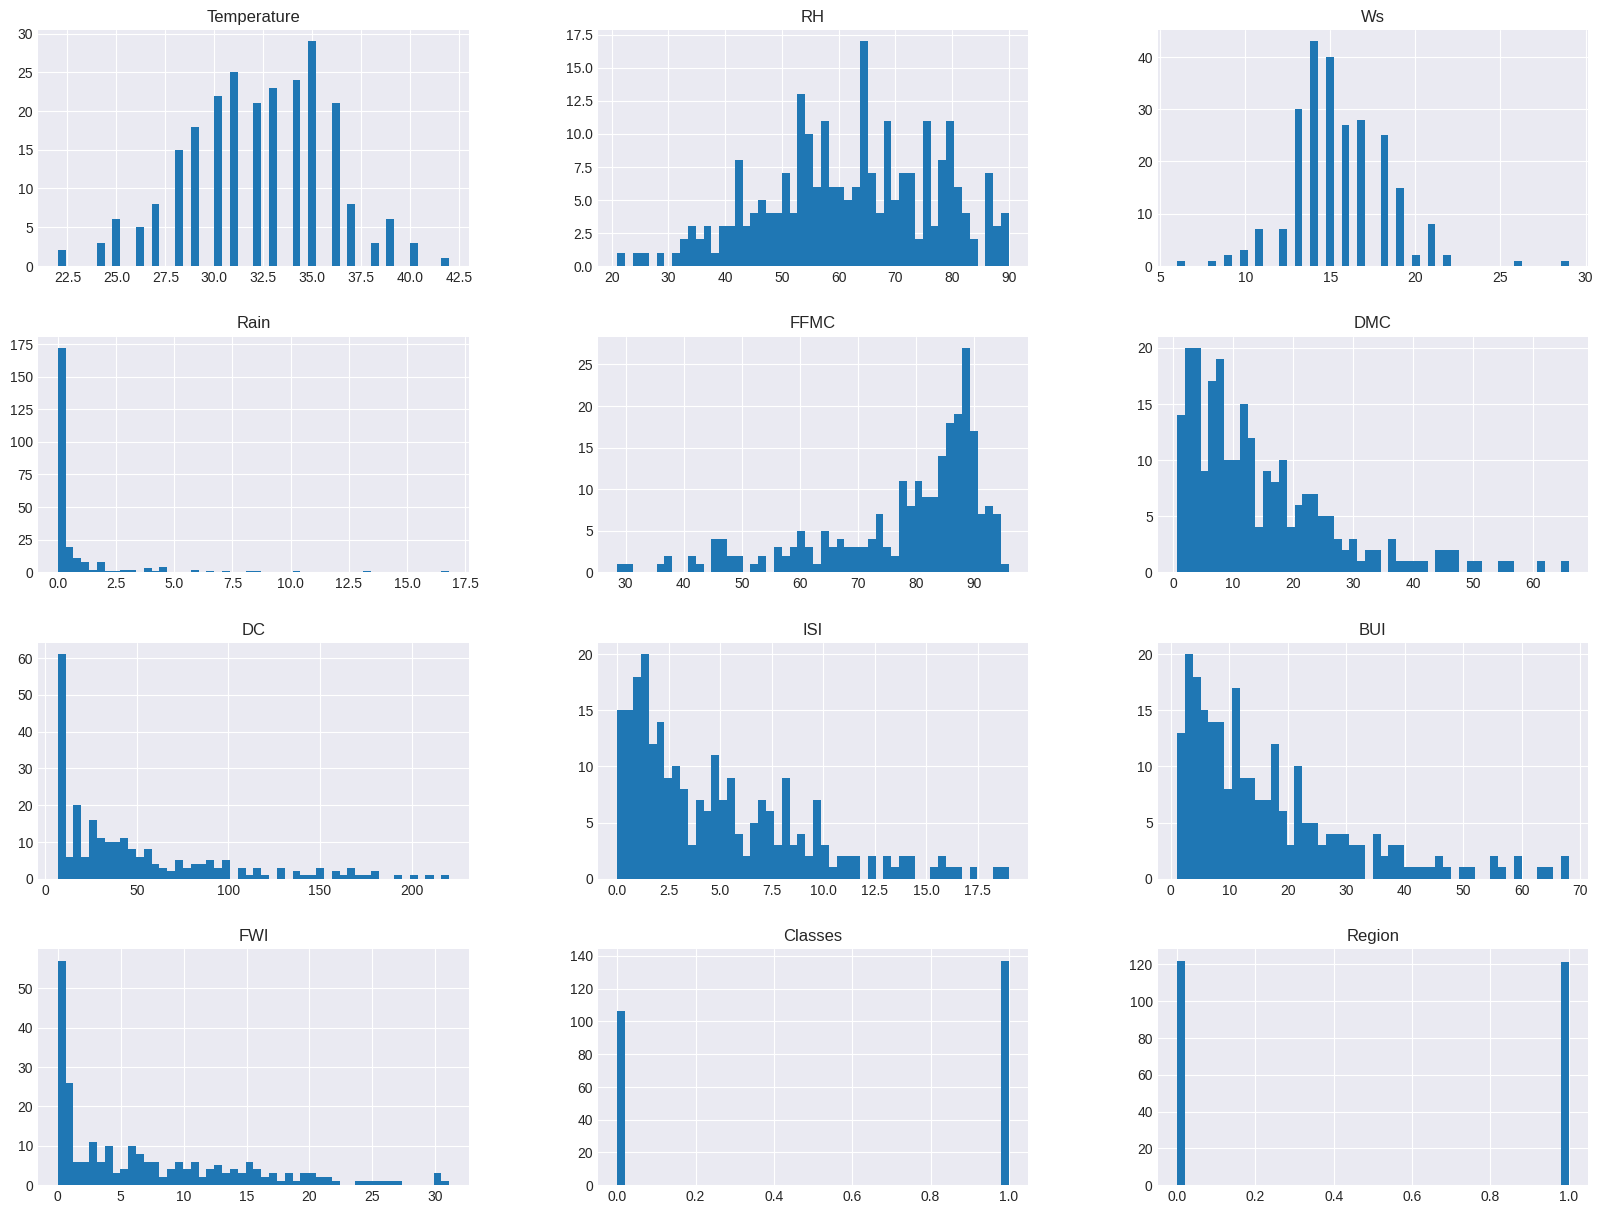

In [37]:
plt.style.use("seaborn-v0_8-dark")
df_copy.hist(bins=50, figsize=(20,15))

In [38]:
# Percentage of pie chart for fire and not fire 
percentage = df_copy["Classes"].value_counts(normalize=True)
percentage

Classes
1    0.563786
0    0.436214
Name: proportion, dtype: float64

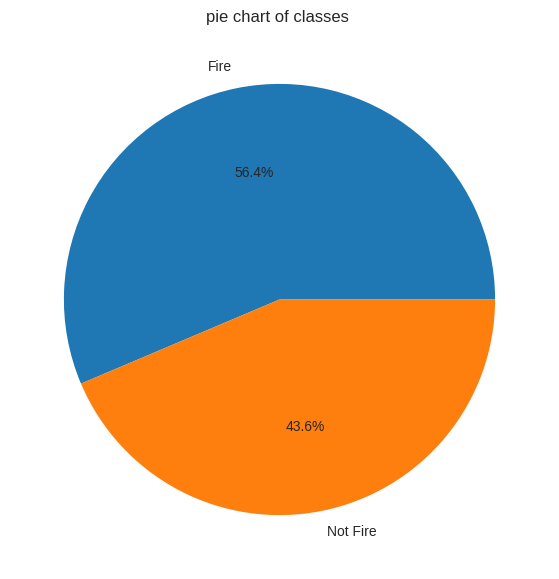

In [39]:
# plot pie chart
Classlabel = ["Fire","Not Fire"]
plt.figure(figsize=(12,7))
plt.pie(percentage, labels=Classlabel, autopct="%1.1f%%")
plt.title("pie chart of classes ")
plt.show()


___
# CoRelation
___

In [40]:
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326483,0.676572,0.485695,0.376276,0.603862,0.459806,0.566657,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222353,-0.644827,-0.408530,-0.226954,-0.686662,-0.353856,-0.580931,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171465,-0.166446,-0.000731,0.079156,0.008519,0.031420,0.032380,-0.069964,-0.181160
Rain,-0.326483,0.222353,0.171465,1.000000,-0.543920,-0.288783,-0.298032,-0.347491,-0.299892,-0.324430,-0.379103,-0.040009
FFMC,0.676572,-0.644827,-0.166446,-0.543920,1.000000,0.603568,0.507296,0.740021,0.591973,0.691114,0.769425,0.222267
DMC,0.485695,-0.408530,-0.000731,-0.288783,0.603568,1.000000,0.875947,0.680454,0.982255,0.875871,0.585658,0.192080
DC,0.376276,-0.226954,0.079156,-0.298032,0.507296,0.875947,1.000000,0.508678,0.941987,0.739563,0.511143,-0.078703
ISI,0.603862,-0.686662,0.008519,-0.347491,0.740021,0.680454,0.508678,1.000000,0.644141,0.922897,0.735198,0.263173
BUI,0.459806,-0.353856,0.031420,-0.299892,0.591973,0.982255,0.941987,0.644141,1.000000,0.858008,0.586663,0.089430
FWI,0.566657,-0.580931,0.032380,-0.324430,0.691114,0.875871,0.739563,0.922897,0.858008,1.000000,0.719216,0.197081


<Axes: >

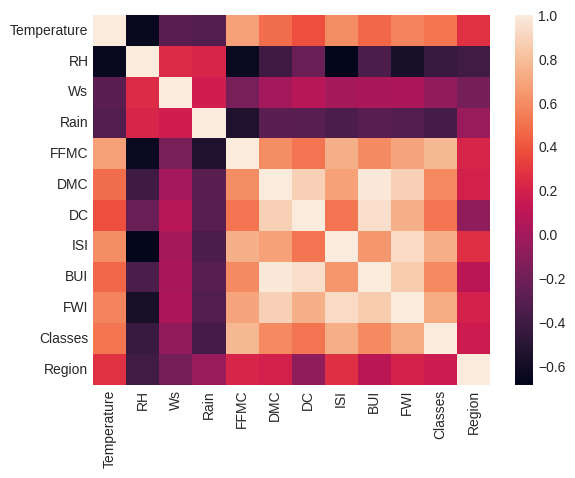

In [41]:
sns.heatmap(df_copy.corr())
# lighter the color more the coralation

<Axes: ylabel='FWI'>

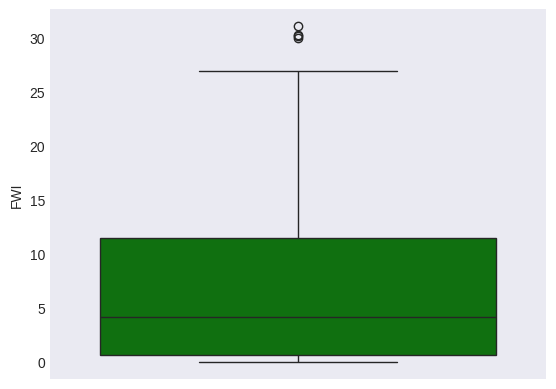

In [42]:
## Box plot 
sns.boxplot(df_copy["FWI"], color = "green")

In [43]:
df.head() # do monthly fire Analysis

/home/aizen/AI_ML/env/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/home/aizen/AI_ML/env/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.000000,65.68750,3.400391,7.601562,1.299805,3.400391,0.500000,not fire,0
1,2,6,2012,29,61,13,1.299805,64.37500,4.101562,7.601562,1.000000,3.900391,0.399902,not fire,0
2,3,6,2012,26,82,22,13.101562,47.09375,2.500000,7.101562,0.300049,2.699219,0.099976,not fire,0
3,4,6,2012,25,89,13,2.500000,28.59375,1.299805,6.898438,0.000000,1.700195,0.000000,not fire,0
4,5,6,2012,27,77,16,0.000000,64.81250,3.000000,14.203125,1.200195,3.900391,0.500000,not fire,0


Text(0.5, 1.0, 'Fire analysis in Bejia Region')

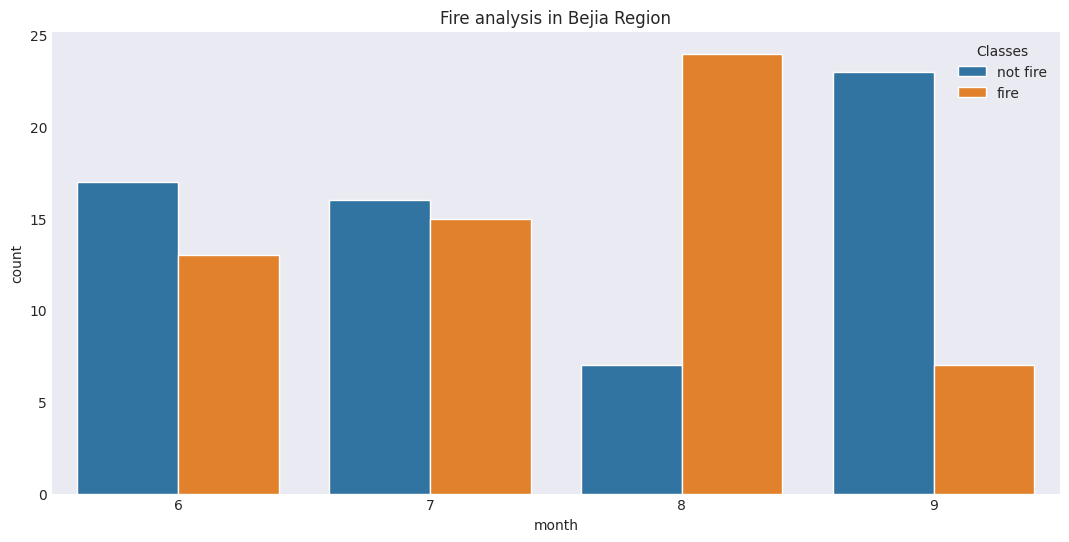

In [44]:
# MONTHLY FIRE ANALYSIS 
df["Classes"] = np.where(df["Classes"].str.contains("not fire"), 'not fire', 'fire')
dftemp = df.loc[df["Region"] == 0]
plt.subplots(figsize = (13,6))
sns.set_style("whitegrid")
sns.countplot(data= dftemp, x = "month", hue = "Classes")
plt.title("Fire analysis in Bejia Region")

Text(0.5, 1.0, 'Fire analysis in Sidi Bel Region')

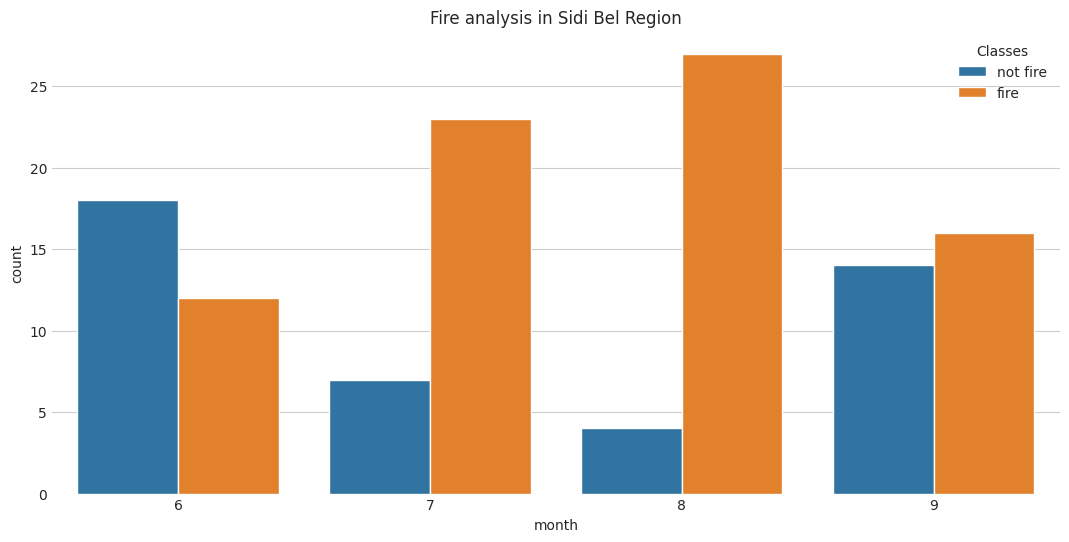

In [45]:
# MONTHLY FIRE ANALYSIS 
df["Classes"] = np.where(df["Classes"].str.contains("not fire"), 'not fire', 'fire')
dftemp = df.loc[df["Region"] == 1]
plt.subplots(figsize = (13,6))
sns.set_style("whitegrid")
sns.countplot(data= dftemp, x = "month", hue = "Classes")
plt.title("Fire analysis in Sidi Bel Region")

___

# Model Training 
___

In [46]:
df_copy.sample(10)

/home/aizen/AI_ML/env/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/home/aizen/AI_ML/env/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
212,30,59,19,0.000000,89.1250,27.796875,168.250000,9.796875,39.312500,19.406250,1,1
58,32,73,15,0.000000,86.6250,26.703125,127.000000,5.601562,35.000000,11.898438,1,0
138,31,69,17,4.699219,62.1875,3.900391,8.000000,1.099609,3.800781,0.399902,0,1
215,28,75,16,0.000000,82.1875,4.398438,24.296875,3.300781,6.000000,2.500000,1,1
226,28,81,15,0.000000,84.6250,12.601562,41.500000,4.300781,14.296875,5.699219,1,1
153,33,48,16,0.000000,87.6250,7.898438,17.796875,6.800781,7.800781,6.398438,1,1
44,30,80,19,0.399902,60.6875,5.199219,17.000000,1.099609,5.898438,0.500000,0,0
123,30,73,13,4.000000,55.6875,2.699219,7.800781,0.600098,2.900391,0.199951,0,1
146,34,70,16,0.000000,86.0000,12.796875,25.593750,5.398438,12.703125,6.699219,1,1
43,34,61,13,0.600098,73.8750,7.800781,22.906250,1.400391,8.398438,0.799805,0,0


In [47]:
df.columns # 

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

___
# Split X and Y 
___

In [48]:
X = df_copy.drop("FWI", axis = 1)  # Independent 
y = df_copy["FWI"]   # Dependent Featue 

In [49]:
X.head()

/home/aizen/AI_ML/env/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/home/aizen/AI_ML/env/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.000000,65.68750,3.400391,7.601562,1.299805,3.400391,0,0
1,29,61,13,1.299805,64.37500,4.101562,7.601562,1.000000,3.900391,0,0
2,26,82,22,13.101562,47.09375,2.500000,7.101562,0.300049,2.699219,0,0
3,25,89,13,2.500000,28.59375,1.299805,6.898438,0.000000,1.700195,0,0
4,27,77,16,0.000000,64.81250,3.000000,14.203125,1.200195,3.900391,0,0


___
# Train Test Split 
___

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
X_train, X_test, y_train, y_test  = train_test_split(X,y, test_size=0.25, random_state=42)

## Feature Selection Based on co relation

In [52]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317502,0.694790,0.498185,0.390686,0.629839,0.473629,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241655,-0.652975,-0.414605,-0.236103,-0.717798,-0.362337,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251895,-0.190010,0.000370,0.096591,-0.023581,0.035611,-0.082570,-0.199969
Rain,-0.317502,0.241655,0.251895,1.000000,-0.545494,-0.289769,-0.302349,-0.345720,-0.301009,-0.369361,-0.059018
FFMC,0.694790,-0.652975,-0.190010,-0.545494,1.000000,0.620772,0.523992,0.750814,0.607162,0.781232,0.249566
DMC,0.498185,-0.414605,0.000370,-0.289769,0.620772,1.000000,0.868672,0.685660,0.983185,0.617286,0.212569
DC,0.390686,-0.236103,0.096591,-0.302349,0.523992,0.868672,1.000000,0.513752,0.942414,0.543607,-0.060790
ISI,0.629839,-0.717798,-0.023581,-0.345720,0.750814,0.685660,0.513752,1.000000,0.643867,0.742986,0.296397
BUI,0.473629,-0.362337,0.035611,-0.301009,0.607162,0.983185,0.942414,0.643867,1.000000,0.612264,0.114918
Classes,0.542141,-0.456876,-0.082570,-0.369361,0.781232,0.617286,0.543607,0.742986,0.612264,1.000000,0.188837


<Axes: >

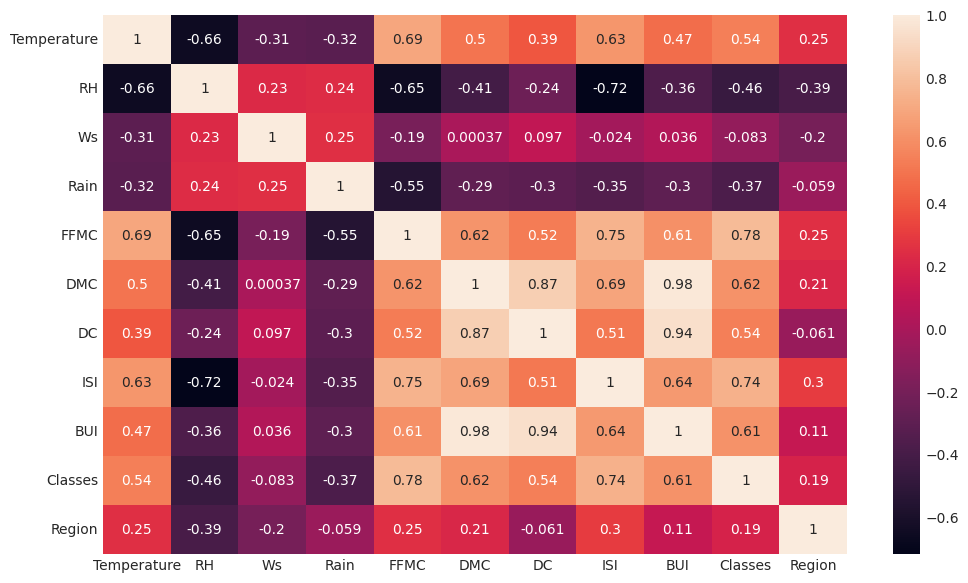

In [53]:
# check for multi-colinearity 
plt.figure(figsize=(12,7))
corr = X_train.corr()
sns.heatmap(corr, annot=True)

# remove those feature that are very highly positively co related 

In [54]:
def correlation(dataset, threshold):
    # Store names of highly correlated columns
    col_corr = set()

    # Compute the correlation matrix of the dataset
    corr_matrix = dataset.corr()

    # Loop through each column in the correlation matrix
    for i in range(len(corr_matrix.columns)):

        # Compare only with previous columns (lower triangle)
        # This avoids duplicate comparisons like A-B and B-A
        for j in range(i):

            # Check if the absolute correlation exceeds the threshold
            if abs(corr_matrix.iloc[i, j]) > threshold:

                # Get the name of the current column
                col_name = corr_matrix.columns[i]

                # Add it to the set of columns to remove
                col_corr.add(col_name)

    # Return all highly correlated column names
    return col_corr

In [55]:
correlation(X_train, 0.95) # Threshold is set by Domain Expert 

{'BUI'}

In [56]:
corr_features = correlation(X_train, 0.85)

In [57]:
# Drop feature at 0.85 threshold 
X_train.drop(corr_features, axis=1 , inplace=True)
X_test.drop(corr_features, axis=1, inplace=True)

___
# Feature Scaling: Standardization
___

In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62973397,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93063277,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.72559281,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.0694961 ,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.59692033,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86122937,
        -1.10431526, -0.98907071]], shape=(182, 9))

Text(0.5, 1.0, 'X_train_scaled')

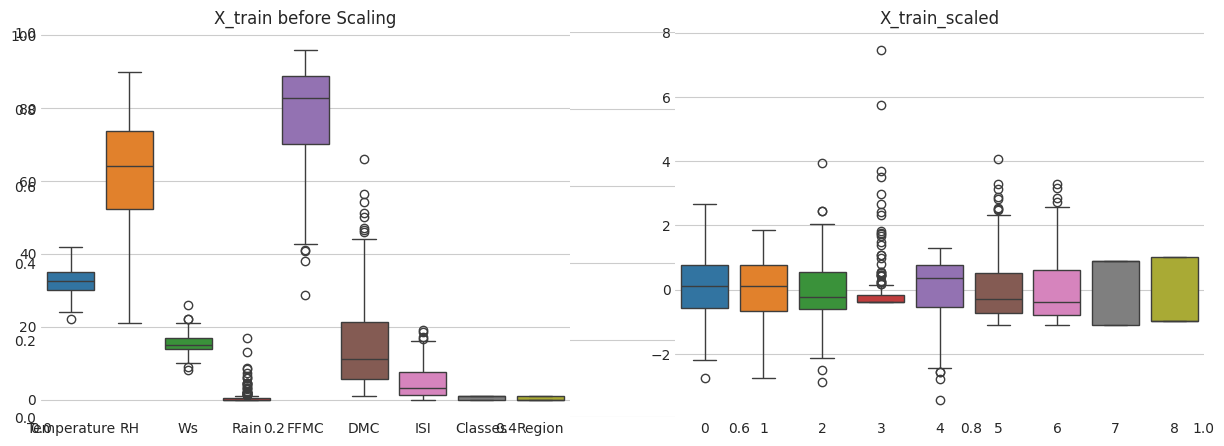

In [61]:
## Box plot to understand effect of Scaller 
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title("X_train before Scaling")
plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)
plt.title("X_train_scaled")

___
# Linear Regression Model 
___

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R² Score:", r2)

MAE: 0.5466770740454501
R² Score: 0.9847747399759853


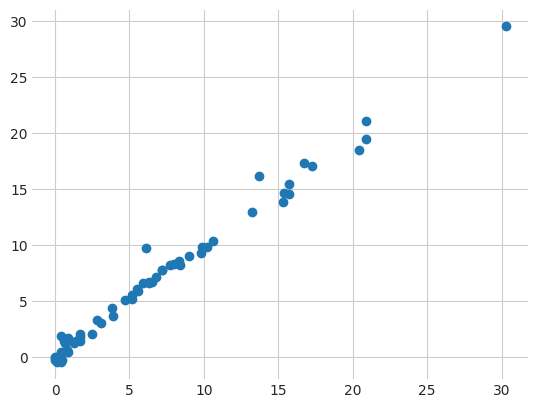

In [64]:
plt.scatter(y_test, y_pred)

___
# Lasso Regression
___

In [65]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score

In [66]:
lasso_model = Lasso()
lasso_model.fit(X_train_scaled, y_train)

y_pred = lasso_model.predict(X_test_scaled)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R² Score:", r2)


MAE: 1.1333285183131125
R² Score: 0.9491889640855738


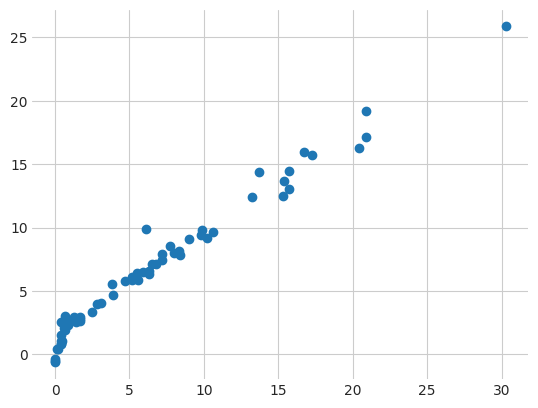

In [67]:
plt.scatter(y_test, y_pred)

___
# Ride Regression
___

In [68]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

In [69]:
ridge_model = Ridge()
ridge_model.fit(X_train_scaled, y_train)

y_pred = ridge_model.predict(X_test_scaled)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R² Score:", r2)


MAE: 0.5641307893141444
R² Score: 0.9843071397417741


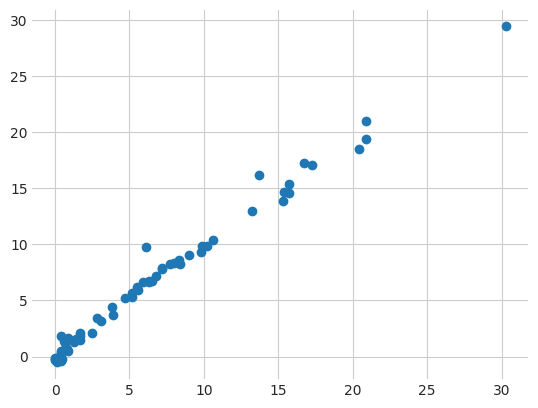

In [70]:
plt.scatter(y_test, y_pred)

___
# Elastic-Net Rigression
___

In [71]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score

In [72]:
ElasticNet_model = ElasticNet()
ElasticNet_model.fit(X_train_scaled, y_train)

y_pred = ElasticNet_model.predict(X_test_scaled)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R² Score:", r2)

MAE: 1.8827461380072532
R² Score: 0.8753281625549408



___
____

# Hyper ParaMeter Tuning

_______
# Cross Validation
___

____
____
____
# LassoCV

`LassoCV` is a version of **Lasso Regression** that automatically finds the **best value of alpha (α)** using **Cross Validation**.

Instead of manually trying different values of alpha, `LassoCV` tests multiple values and selects the one that gives the best performance.

---

## Why Do We Use LassoCV?

Without `LassoCV`:

```python id="4zbhxl"
Lasso(alpha=0.1)
Lasso(alpha=1)
Lasso(alpha=10)
```

You have to guess the best value of `alpha`.

With `LassoCV`:

```python id="klfxhl"
LassoCV()
```

Scikit-Learn automatically finds the best alpha.

---

## What is Alpha (α)?

Alpha controls the amount of regularization.

| Alpha   | Effect                    |
| ------- | ------------------------- |
| Small α | Less regularization       |
| Large α | More regularization       |
| α = 0   | Same as Linear Regression |

---

## How LassoCV Works

```text id="7drjti"
Training Data
      ↓
Try Many Alpha Values
      ↓
Cross Validation
      ↓
Calculate Error
      ↓
Choose Best Alpha
      ↓
Train Final Model
```

---

## Scikit-Learn Syntax

```python id="9ftjlwm"
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(
    cv=5,
    random_state=42
)

lasso_cv.fit(X_train_scaled, y_train)
```

---

## Predict

```python id="2uhy1b"
y_pred = lasso_cv.predict(X_test_scaled)
```

---

## Important Parameters

### `cv`

Number of cross-validation folds.

```python id="m8vvfw"
cv=5
```

Common values:

```python id="27lqxr"
cv=3
cv=5
cv=10
```

---

### `random_state`

Ensures reproducible results.

```python id="l3g87y"
random_state=42
```

---

### `max_iter`

Maximum number of iterations.

```python id="9klloq"
max_iter=10000
```

Useful when the model does not converge.

---

## Finding the Best Alpha

After training:

```python id="6mj2oc"
print(lasso_cv.alpha_)
```

Example:

```text id="u5h8ci"
0.023
```

This is the alpha selected by cross-validation.

---

## Model Coefficients

```python id="myq6lg"
print(lasso_cv.coef_)
```

Lasso may set some coefficients exactly to **0**.

Example:

```text id="qwewl2"
[2.4, 0.0, -1.8, 0.0, 5.2]
```

This means the second and fourth features are removed from the model.

---

## Complete Example

```python id="qwpn35"
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(
    cv=5,
    random_state=42
)

lasso_cv.fit(X_train_scaled, y_train)

y_pred = lasso_cv.predict(X_test_scaled)

print("Best Alpha:", lasso_cv.alpha_)
```

---

## Lasso vs LassoCV

| Lasso                    | LassoCV                       |
| ------------------------ | ----------------------------- |
| Alpha is chosen manually | Alpha is chosen automatically |
| No cross validation      | Uses cross validation         |
| More trial and error     | More convenient and reliable  |

---

## One-Line Definition

> **LassoCV automatically finds the best regularization strength (alpha) using cross-validation and then trains the final Lasso Regression model with that optimal alpha.**


____
____

In [73]:
from sklearn.linear_model import LassoCV

In [74]:
lasso_cv = LassoCV(cv=5) # 

lasso_cv.fit(X_train_scaled, y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


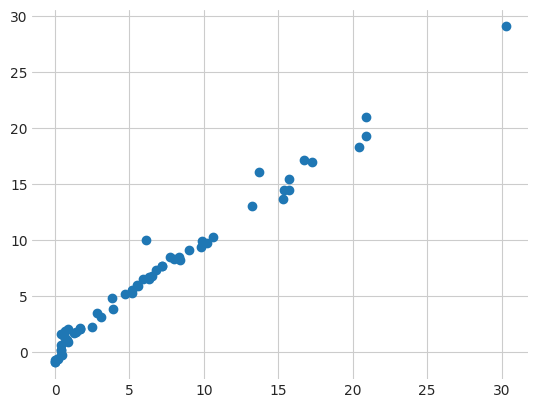

In [75]:
y_pred = lasso_cv.predict(X_test_scaled)
plt.scatter(y_test, y_pred )

In [76]:
# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R² Score:", r2)

MAE: 0.6358730743234599
R² Score: 0.9814464132825348


In [77]:
lasso_cv.alpha_ # this alpha is selected

np.float64(0.06582757429072471)

In [78]:
lasso_cv.alphas_ # these are the alpha it tried 

array([7.05847502, 6.58275743, 6.13910161, 5.72534671, 5.3394775 ,
       4.97961459, 4.64400523, 4.33101482, 4.03911892, 3.76689582,
       3.51301965, 3.27625388, 3.05544534, 2.84951855, 2.65747054,
       2.47836592, 2.31133235, 2.15555628, 2.010279  , 1.87479293,
       1.74843816, 1.63059928, 1.52070234, 1.4182121 , 1.32262935,
       1.23348856, 1.15035556, 1.07282544, 1.0005206 , 0.93308886,
       0.87020179, 0.8115531 , 0.75685714, 0.7058475 , 0.65827574,
       0.61391016, 0.57253467, 0.53394775, 0.49796146, 0.46440052,
       0.43310148, 0.40391189, 0.37668958, 0.35130197, 0.32762539,
       0.30554453, 0.28495185, 0.26574705, 0.24783659, 0.23113323,
       0.21555563, 0.2010279 , 0.18747929, 0.17484382, 0.16305993,
       0.15207023, 0.14182121, 0.13226293, 0.12334886, 0.11503556,
       0.10728254, 0.10005206, 0.09330889, 0.08702018, 0.08115531,
       0.07568571, 0.07058475, 0.06582757, 0.06139102, 0.05725347,
       0.05339478, 0.04979615, 0.04644005, 0.04331015, 0.04039

___
# Ridge CV
___

In [79]:
from sklearn.linear_model import RidgeCV

In [80]:
ridge_cv = RidgeCV(cv = 5)
ridge_cv.fit(X_train_scaled, y_train)

,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.","(0.1, ...)"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : use 'svd' if n_samples > n_features, otherwise use 'eigen' 'svd' : force use of singular value decomposition of X when X is dense, eigenvalue decomposition of X^T.X when X is sparse. 'eigen' : force computation via eigendecomposition of X.X^TThe 'auto' mode is the default and is intended to pick the cheaperoption of the two depending on the shape of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets... versionadded:: 0.24",False


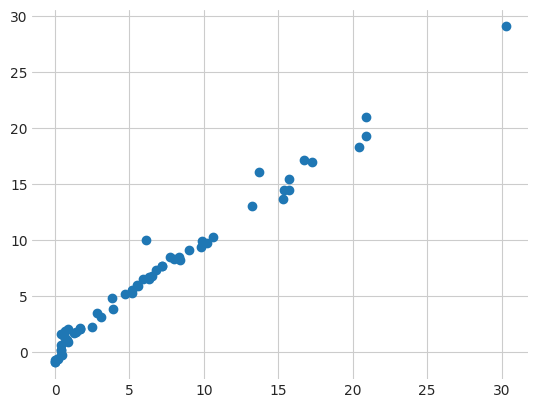

In [81]:
y_pred = lasso_cv.predict(X_test_scaled)
plt.scatter(y_test, y_pred )

In [82]:
# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R² Score:", r2)

MAE: 0.6358730743234599
R² Score: 0.9814464132825348


In [83]:
ridge_cv.alpha_

np.float64(1.0)

In [84]:
ridge_cv.alphas

(0.1, 1.0, 10.0)

___
# Elastic Net Cv
___

In [85]:
from sklearn.linear_model import ElasticNetCV

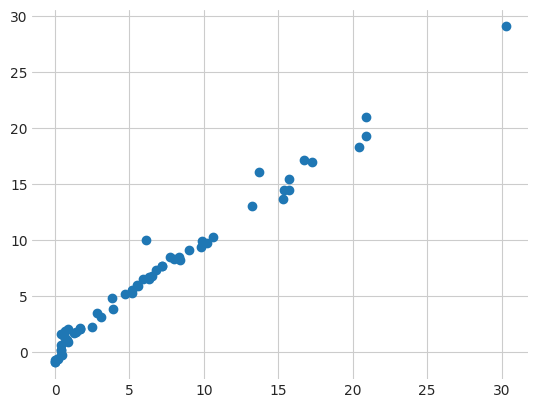

In [86]:
ElasticNet_cv = ElasticNetCV(cv=5)
ElasticNet_cv.fit(X_train_scaled, y_train)

y_pred = lasso_cv.predict(X_test_scaled)
plt.scatter(y_test, y_pred )

In [87]:
# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R² Score:", r2)

MAE: 0.6358730743234599
R² Score: 0.9814464132825348


___
___

# Pickling Models


# Saving the Model : Pickle

    After training, the model lives in RAM — when you close the notebook it is gone

    pickle saves the trained model to your hard disk as a .pkl file
    Later, Flask loads it from disk — no retraining needed

    Think of it like this :
    Training  →  model learns everything
    pickle.dump()  →  saves that knowledge to disk
    pickle.load()  →  loads it back into memory later

    We save 3 things :
    1. scaler      → StandardScaler (fitted on X_train)
    2. model       → the best trained model (Ridge or Lasso)
    3. feature names → so Flask knows which columns to expect

___
___

In [ ]:
import pickle
import os

In [ ]:


os.makedirs("models", exist_ok=True)  # this is will a directory in parent directory 

In [102]:
# =====================================================
# SAVE THE TRAINED RIDGE MODEL TO A FILE
# =====================================================

# 'with' is a context manager.
# It opens the file, lets us work with it,
# and automatically closes it when we're done.
# This prevents file corruption and memory leaks.

with open("models/scaler.pkl", "wb") as f:  # wb : if file doesnt exist it creates it 
                                                 # store file object inside variable f 

    # pickle.dump() serializes (converts) the Python object
    # into binary data and writes it into the file.
    #
    # Syntax:
    # pickle.dump(object_to_save, file_object)
    #
    # object_to_save -> The Python object you want to store
    #                    (our trained RidgeCV model)
    #
    # file_object -> The opened file where the object
    #                should be written.
    #
    # After this line executes,
    # the trained model is stored inside:
    # models/ridge_model.pkl
    #
    pickle.dump(scaler, f)

# Once execution leaves the 'with' block,
# Python automatically closes the file.

print("✅ Scaler saved → models/scaler.pkl")

✅ Scaler saved → models/scaler.pkl


In [100]:
# The the BEST Model
# Save the best model
# Ridge CV gave best results — saving that one

with open("models/ridge_model_cv.pkl", "wb") as f: 
    pickle.dump(ridge_cv, f)                     

print("✅ ridge model saved → models/ridge_model.pkl")

✅ ridge model saved → models/ridge_model.pkl


In [93]:
# Just for Practice I am Saving All the models 
# ---- Save Linear Regression ----
with open("models/linear_model.pkl", "wb") as f:
    pickle.dump(model, f)
print("✅ linear regression saved")


# ---- Save Lasso ----

with open("models/lasso_model.pkl", "wb") as f:
    pickle.dump(lasso_model, f)
print("✅ lasso saved")

# ---- Save Ridge ----
with open("models/ridge_model.pkl", "wb") as f:
    pickle.dump(ridge_model, f)
print("✅ ridge saved")

# ---- Save ElasticNet ----
with open("models/elasticnet_model.pkl", "wb") as f:
    pickle.dump(ElasticNet_model, f)
print("✅ elasticnet saved")




# ---- Save LassoCV ----
with open("models/lasso_cv_model.pkl", "wb") as f:
    pickle.dump(lasso_cv, f)
print("✅ lasso cv saved")



# ---- Save ElasticNetCV ----
with open("models/elasticnet_cv_model.pkl", "wb") as f:
    pickle.dump(ElasticNet_cv, f)
print("✅ elasticnet cv saved")

✅ linear regression saved
✅ lasso saved
✅ ridge saved
✅ elasticnet saved
✅ lasso cv saved
✅ elasticnet cv saved


In [94]:
# Save feature column names
# Flask will need to know which features to expect in the same order

feature_columns = list(X_train.columns)   # X_train after dropping correlated features

with open("models/feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("✅ feature columns saved → models/feature_columns.pkl")
print("Columns:", feature_columns)

✅ feature columns saved → models/feature_columns.pkl
Columns: ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'ISI', 'Classes', 'Region']


In [97]:
# Verify — load them back and test
# This confirms the files are not corrupted before we build Flask

with open("models/scaler.pkl" , "rb") as f: 
    test_scaler = pickle.load(f)

with open("models/ridge_model.pkl", "rb") as f:
    test_model = pickle.load(f)

with open("models/feature_columns.pkl", "rb") as f:
    test_cols = pickle.load(f)

print("✅ All files loaded successfully")
print("Feature columns:", test_cols)
print("Model type     :", type(test_model))
print("Scaler type    :", type(test_scaler))

✅ All files loaded successfully
Feature columns: ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'ISI', 'Classes', 'Region']
Model type     : <class 'sklearn.linear_model._ridge.Ridge'>
Scaler type    : <class 'sklearn.preprocessing._data.StandardScaler'>


In [98]:
# Testing the model that we load above from models folder
# we loaded : ridge_model as test_model
#             scaler as test_scaler
#             columns as test_columns 

# Take one row from X_test
sample = X_test.iloc[[0]]            # double bracket keeps it as DataFrame
sample_scaled = test_scaler.transform(sample)
prediction    = test_model.predict(sample_scaled)

print("Sample input    :", sample.values)
print("Actual FWI      :", y_test.iloc[0])
print("Predicted FWI   :", round(prediction[0], 2))
print("✅ Pickle files working correctly — ready for Flask")

Sample input    : [[31 64 15 0.0 86.6875 14.203125 5.69921875 1 0]]
Actual FWI      : 8.4
Predicted FWI   : 8.24
✅ Pickle files working correctly — ready for Flask


___
___
___

# Why Do We Need Ridge and Lasso Regression?

Before understanding **LassoCV**, we first need to understand **why Ridge and Lasso Regression exist.**

---

# The Problem with Linear Regression

Linear Regression tries to fit the training data as closely as possible.

If the dataset has:

* Too many features
* Noisy data
* Highly correlated features
* Complex relationships

the model may **memorize the training data** instead of learning the real pattern.

This is called **Overfitting**.

```text id="d1tjlwm"
Training Accuracy : 99%

Testing Accuracy  : 72%
```

The model performs well on training data but poorly on new data.

---

# Solution: Regularization

Regularization is a technique that **reduces the complexity of the model** by discouraging very large coefficients.

Instead of only minimizing prediction error, the model is also penalized for having large weights.

Goal:

```text id="r6qsb5"
Good Accuracy
        +
Simpler Model
```

---

# Why Are Large Coefficients Bad?

Suppose we predict house prices.

Linear Regression learns:

$$
Price
=====

2
+
1500(Area)
+
9000(Bedrooms)
+
250000(Age)
$$

Notice that one coefficient is extremely large.

Large coefficients usually mean:

* The model is fitting noise.
* The model becomes unstable.
* Small changes in input can produce huge changes in predictions.

---

# Ridge and Lasso Fix This

Instead of allowing coefficients to grow freely, they penalize large coefficients.

```text id="aj5hmg"
Before Regularization

Area      = 1500
Bedrooms  = 9000
Age       = 250000
```

↓

```text id="0s0t0r"
After Regularization

Area      = 1200
Bedrooms  = 4500
Age       = 15000
```

The model becomes more stable and generalizes better.

---

# What is Alpha (α)?

Alpha controls **how much regularization** is applied.

Think of alpha as a **regularization strength knob**.

```text id="jkddyr"
Alpha
  ↑
More Penalty
```

---

## Small Alpha

```text id="huzmyb"
α = 0.0001
```

Very little regularization.

The model behaves almost like Linear Regression.

---

## Medium Alpha

```text id="5z52es"
α = 1
```

A balance between:

* Fitting the data
* Keeping the model simple

---

## Large Alpha

```text id="80u25u"
α = 1000
```

Very strong regularization.

The model becomes too simple and may **underfit**.

---

# Visual Intuition

```text id="z5aebm"
Small α

Complex Model
~~~~~~~~~~~~~~
```

↓

```text id="e0r37o"
Medium α

Smooth Curve
___________
```

↓

```text id="lb3w3l"
Large α

Almost Flat
-----------
```

---

# Why Can't We Pick Alpha Ourselves?

Suppose we try:

```python id="qv8b2c"
alpha = 0.001
```

Will it be good?

We don't know.

Try:

```python id="q5u3yh"
alpha = 1
```

Maybe.

Try:

```python id="oqu9zs"
alpha = 50
```

Maybe worse.

There is **no universal best alpha**.

It depends on:

* Dataset
* Number of features
* Noise
* Target variable

---

# This is Why We Use LassoCV

Instead of guessing alpha manually, **LassoCV** automatically tries many alpha values.

Example:

```text id="vxpup2"
0.0001
0.001
0.01
0.1
1
10
100
```

For each alpha:

1. Train the model.
2. Perform Cross Validation.
3. Calculate the validation error.

Finally:

```text id="i91qol"
Choose Alpha
with the Lowest Error
```

---

# How LassoCV Works

```text id="vz4f1x"
Training Data
      │
      ▼
Try Many Alpha Values
      │
      ▼
Cross Validation
      │
      ▼
Calculate Validation Error
      │
      ▼
Select Best Alpha
      │
      ▼
Train Final Lasso Model
```

---

# Ridge vs Lasso

## Ridge Regression

Ridge **shrinks** coefficients.

Example:

```text id="pqsmg8"
Before

Area = 1200
Age = 500
Rooms = 900
```

↓

```text id="2kq71e"
After

Area = 900
Age = 320
Rooms = 700
```

Notice:

No coefficient becomes exactly **0**.

---

## Lasso Regression

Lasso also shrinks coefficients.

But it can completely remove unimportant features.

Example:

```text id="wfes0c"
Before

Area = 1200
Age = 500
Rooms = 900
Parking = 150
```

↓

```text id="gbwjbd"
After

Area = 900
Age = 0
Rooms = 650
Parking = 0
```

Lasso performs **feature selection**.

---

# When Should We Use Them?

### Use Ridge when:

* Most features are useful.
* You only want to reduce overfitting.

---

### Use Lasso when:

* Some features are unimportant.
* You want automatic feature selection.

---

# One-Line Summary

* **Linear Regression:** Fits the data without any penalty.
* **Ridge Regression:** Adds a penalty to shrink coefficients and reduce overfitting.
* **Lasso Regression:** Adds a penalty that shrinks coefficients and can set unimportant ones to **0**, effectively selecting features.
* **LassoCV:** Automatically finds the best value of **alpha** using cross-validation, removing the need for manual tuning.
